# **Feature Group Model Comparison**

This notebook compares different environmental feature groups for food insecurity risk classification.

The goal is to test whether rainfall features, NDVI features, or the combined rainfall + NDVI feature set performs best for predicting high-risk county-periods.

This helps explain which environmental signals contribute most to the early-warning model.

## **Load and Prepare Dataset**

This notebook uses the master modeling dataset created earlier in the project.

The dataset combines:

- IPC food insecurity outcomes
- CHIRPS rainfall indicators
- MODIS NDVI vegetation indicators

The same high-risk target definition is used:

- `1` = High Risk
- `0` = Not High Risk

A county-period is classified as high risk if 20% or more of the population is in IPC Phase 3 or worse.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

# Load master dataset
df = pd.read_csv("../02_data/processed/ipc_rainfall_ndvi_master_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (322, 19)


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg,date,mean_ndvi,ndvi_1_month_mean,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,172.723779,47.813818,28.787296,2019-06-01,0.645498,0.645498,0.469621,0.424800,0.078739
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,156.388124,41.315655,26.064687,2019-06-01,0.710059,0.710059,0.715939,0.708263,-0.026823
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,66.812339,18.395066,11.135390,2019-06-01,0.211246,0.211246,0.247841,0.247458,-0.047864
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,40.062429,8.863886,6.677072,2019-06-01,0.207090,0.207090,0.223339,0.220767,-0.042075
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,88.344720,20.905620,14.724120,2019-06-01,0.379489,0.379489,0.389526,0.366431,-0.030230


## **Prepare Target and Time-Aware Split**

Before comparing feature groups, I recreate the same high-risk target used in the baseline modeling notebook.

A county-period is classified as high risk if **20% or more of the population is in IPC Phase 3 or worse**.

The dataset is then sorted by IPC date and split in time order:

- Earlier records are used for training.
- Later records are used for testing.

This keeps the experiment consistent with the baseline model and avoids randomly mixing past and future records.

In [3]:
# Convert IPC date to datetime
df["ipc_date"] = pd.to_datetime(df["ipc_date"])

# Create binary target variable
threshold = 0.20
df["high_risk"] = (df["phase_3_plus_percentage"] >= threshold).astype(int)

# Sort by date for time-aware modeling
df = df.sort_values("ipc_date").reset_index(drop=True)

# Create time-aware train-test split
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Dataset shape:", df.shape)
print("Date range:", df["ipc_date"].min(), "to", df["ipc_date"].max())

print("\nTrain set:")
print("Rows:", len(train_df))
print("Date range:", train_df["ipc_date"].min(), "to", train_df["ipc_date"].max())
print("High-risk cases:", train_df["high_risk"].sum())

print("\nTest set:")
print("Rows:", len(test_df))
print("Date range:", test_df["ipc_date"].min(), "to", test_df["ipc_date"].max())
print("High-risk cases:", test_df["high_risk"].sum())

Dataset shape: (322, 20)
Date range: 2019-07-01 00:00:00 to 2026-02-01 00:00:00

Train set:
Rows: 257
Date range: 2019-07-01 00:00:00 to 2025-02-01 00:00:00
High-risk cases: 76

Test set:
Rows: 65
Date range: 2025-02-01 00:00:00 to 2026-02-01 00:00:00
High-risk cases: 16


## **Define Feature Groups**

This experiment compares three groups of environmental predictors:

1. **Rainfall-only features**
   - Uses CHIRPS rainfall indicators only.

2. **NDVI-only features**
   - Uses MODIS NDVI vegetation health indicators only.

3. **Combined rainfall + NDVI features**
   - Uses both rainfall and NDVI indicators together.

The same train-test split will be used for all three feature groups so that the comparison is fair.

In [4]:
# Define rainfall-only features
rainfall_features = [
    "mean_rainfall_mm",
    "rainfall_3_month_total",
    "rainfall_6_month_total",
    "rainfall_3_month_avg",
    "rainfall_6_month_avg"
]

# Define NDVI-only features
ndvi_features = [
    "mean_ndvi",
    "ndvi_1_month_mean",
    "ndvi_3_month_mean",
    "ndvi_6_month_mean",
    "ndvi_anomaly"
]

# Define combined rainfall + NDVI features
combined_features = rainfall_features + ndvi_features

print("Rainfall features:", len(rainfall_features))
print(rainfall_features)

print("\nNDVI features:", len(ndvi_features))
print(ndvi_features)

print("\nCombined features:", len(combined_features))
print(combined_features)

Rainfall features: 5
['mean_rainfall_mm', 'rainfall_3_month_total', 'rainfall_6_month_total', 'rainfall_3_month_avg', 'rainfall_6_month_avg']

NDVI features: 5
['mean_ndvi', 'ndvi_1_month_mean', 'ndvi_3_month_mean', 'ndvi_6_month_mean', 'ndvi_anomaly']

Combined features: 10
['mean_rainfall_mm', 'rainfall_3_month_total', 'rainfall_6_month_total', 'rainfall_3_month_avg', 'rainfall_6_month_avg', 'mean_ndvi', 'ndvi_1_month_mean', 'ndvi_3_month_mean', 'ndvi_6_month_mean', 'ndvi_anomaly']


## **Train and Evaluate Feature Group Models**

To compare the feature groups fairly, I train the same XGBoost model structure on each feature group.

The only thing that changes is the input features:

- Rainfall-only model
- NDVI-only model
- Combined rainfall + NDVI model

Each model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

In [6]:
def train_evaluate_xgboost(feature_columns, model_name):
    """
    Train and evaluate an XGBoost model using a selected feature group.
    """

    X_train = train_df[feature_columns]
    y_train = train_df["high_risk"]

    X_test = test_df[feature_columns]
    y_test = test_df["high_risk"]

    # Class imbalance weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        min_child_weight=5,
        gamma=1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "model": model_name,
        "feature_count": len(feature_columns),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_pred_prob)
    }

    return results, model

## **Run Feature Group Models**

Now I train and evaluate three XGBoost models:

1. Rainfall-only model
2. NDVI-only model
3. Combined rainfall + NDVI model

Each model uses the same train-test split and the same XGBoost settings. This makes the comparison fair because only the feature group changes.

In [7]:
# Train and evaluate rainfall-only model
rainfall_results, rainfall_model = train_evaluate_xgboost(
    rainfall_features,
    "Rainfall Only"
)

# Train and evaluate NDVI-only model
ndvi_results, ndvi_model = train_evaluate_xgboost(
    ndvi_features,
    "NDVI Only"
)

# Train and evaluate combined rainfall + NDVI model
combined_results, combined_model = train_evaluate_xgboost(
    combined_features,
    "Rainfall + NDVI"
)

# Combine results into one table
feature_group_results = pd.DataFrame([
    rainfall_results,
    ndvi_results,
    combined_results
])

feature_group_results

,model,feature_count,accuracy,precision,recall,f1_score,roc_auc
0,Rainfall Only,5,0.800000,0.571429,0.7500,0.648649,0.828444
1,NDVI Only,5,0.876923,0.722222,0.8125,0.764706,0.931122
2,Rainfall + NDVI,10,0.876923,0.700000,0.8750,0.777778,0.936224


### **Interpretation**

The feature group comparison shows that rainfall indicators alone provide useful predictive signal, but they are weaker than NDVI vegetation indicators.

The Rainfall Only model achieved reasonable performance, but it had the lowest F1-score and ROC-AUC among the three models. This suggests that rainfall alone does not fully capture food insecurity risk.

The NDVI Only model performed much better than the Rainfall Only model. This supports the earlier exploratory analysis, where NDVI indicators showed stronger relationships with Phase 3+ food insecurity burden. Vegetation health appears to be a strong early-warning signal because it reflects how rainfall conditions affect pasture, crops, and land productivity over time.

The Combined Rainfall + NDVI model produced the strongest overall performance. It achieved the highest recall, F1-score, and ROC-AUC. This means the model was better at identifying true high-risk cases while also maintaining a stronger overall balance between precision and recall.

The key takeaway is that NDVI is more predictive than rainfall alone, but combining rainfall and NDVI gives the best early-warning performance.

## **Visualize Feature Group Performance**

To make the comparison easier to understand, I visualize the most important evaluation metrics across the three feature groups.

For this early-warning project, the most important metrics are:

- **Recall**: how well the model catches true high-risk cases
- **F1-score**: balance between precision and recall
- **ROC-AUC**: how well the model separates high-risk from non-high-risk cases

This chart helps show whether rainfall, NDVI, or the combined feature set gives the strongest predictive performance.

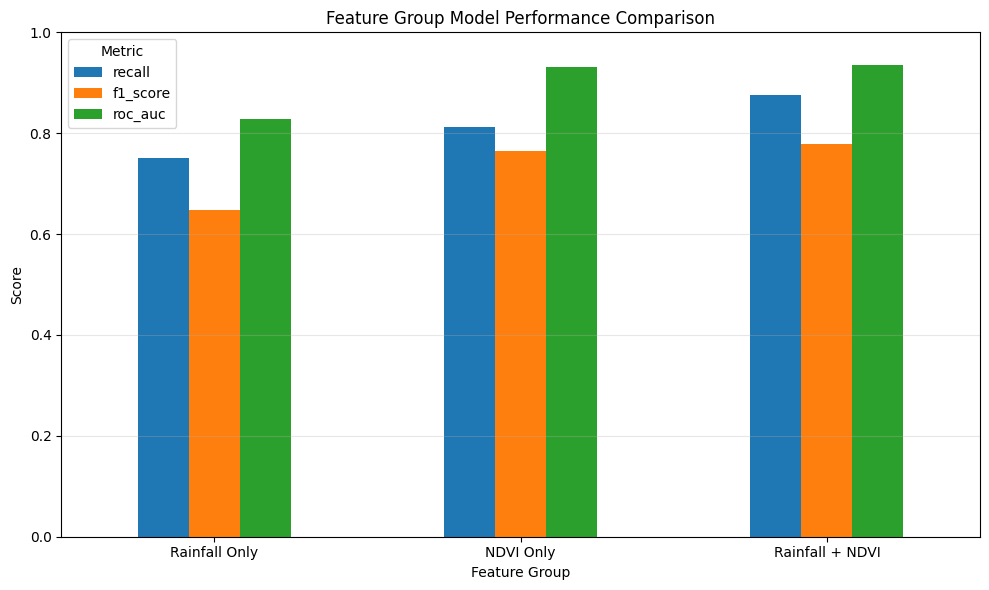

In [8]:
# Select key metrics for visualization
metrics_to_plot = ["recall", "f1_score", "roc_auc"]

# Prepare data for plotting
plot_data = feature_group_results[["model"] + metrics_to_plot].set_index("model")

# Plot grouped bar chart
ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Feature Group Model Performance Comparison")
plt.xlabel("Feature Group")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### **Interpretation**

The chart shows that the Rainfall Only model performs the weakest across the key early-warning metrics.

The NDVI Only model performs much better than the Rainfall Only model, especially on F1-score and ROC-AUC. This suggests that vegetation health contains stronger predictive information than rainfall alone.

The Combined Rainfall + NDVI model performs best overall. It achieves the strongest recall, F1-score, and ROC-AUC, meaning it is better at catching high-risk cases while still maintaining a good balance between correct alerts and false alarms.

This supports the decision to use both rainfall and NDVI indicators in the baseline early-warning model.

## **Save Feature Group Comparison Results**

The comparison table is saved as a CSV file so it can be reused in the project documentation, README, or future dashboard improvements.

In [9]:
# Save feature group comparison results
output_path = "../02_data/processed/feature_group_model_comparison.csv"

feature_group_results.to_csv(output_path, index=False)

print("Feature group comparison saved to:", output_path)
print("Output shape:", feature_group_results.shape)

Feature group comparison saved to: ../02_data/processed/feature_group_model_comparison.csv
Output shape: (3, 7)


## **Conclusion**

This notebook compared three environmental feature groups for predicting high-risk food insecurity cases across Kenya ASAL counties.

The three feature groups were:

- Rainfall-only features
- NDVI-only features
- Combined rainfall + NDVI features

The results show that the Rainfall Only model had the weakest performance among the three models.

The NDVI Only model performed much better than the Rainfall Only model. This supports the earlier exploratory analysis, where NDVI indicators showed stronger relationships with Phase 3+ food insecurity burden.

The Combined Rainfall + NDVI model performed best overall. It achieved the strongest recall, F1-score, and ROC-AUC, making it the best feature group for the current early-warning model.

The main takeaway is:

**NDVI vegetation indicators are stronger than rainfall indicators alone, but combining rainfall and NDVI gives the best prediction performance.**

This supports the current project decision to use both rainfall and NDVI indicators in the baseline food insecurity risk model.

## **Next Step**

The next stage is to improve the project by adding additional predictors beyond rainfall and NDVI.

Possible next predictors include:

- cereal market prices
- livestock conditions
- market access indicators
- drought bulletin indicators
- longer time-lag features

Adding these predictors may help capture food insecurity drivers that rainfall and vegetation data alone cannot fully explain.